<h1>import libraries</h1>

In [5]:
import pickle # save and load python objects
import json # stores and reads data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # builds untop a matplotlib and maks certain statistical plot easier

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

tf.random.set_seed(42)
np.random.seed(42)  # seed mean random numbers that don't change each time you run the code 

<h1>load dataset</h1>
train, validate and test the data loaded

In [6]:
train_df = pd.read_csv('diabetes_train.csv')
val_df = pd.read_csv('diabetes_val.csv')  
test_df = pd.read_csv('diabetes_test.csv')

X_train = train_df.drop(columns=['Outcome']).values.astype(np.float32)
Y_train = train_df['Outcome'].values.astype(np.float32)

X_val = val_df.drop(columns=['Outcome']).values.astype(np.float32)
Y_val = val_df['Outcome'].values.astype(np.float32)

X_test = val_df.drop(columns=['Outcome']).values.astype(np.float32)
Y_test = val_df['Outcome'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

Train: (537, 14)
Val: (115, 14)
Test: (115, 14)
Number of features: 14


In [1]:
with open("diabetes_metadata.json") as f:
    metadata = json.load(f) # metadata: info that describes the data. converting the data into  a dictionary formate

feature_cols = metadata['feature_cols']
train_medians = metadata['train_medians']
scaler_mean = np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f"Loaded metadat for {len(feature_cols)} features")

scaler_scale

NameError: name 'json' is not defined

In [9]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')


    
    # block 1
    x = keras.layers.Dense(128, kernel_regularizer= keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    # block 2
    x = keras.layers.Dense(32)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    #block 3
    x = keras.layers.Dense(32)(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    #output: a single probability
    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)
    return keras.models.Model(inputs, outputs, name='DiabetesANN')

model = build_ann(X_train.shape[1])
model.summary()

Model: "DiabetesANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 14)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,777 (30.38 KB)

 Trainable params: 7,457 (29.13 KB)

 Non-trainable params: 320 (1.25 KB)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', varbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_diabetes.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0),
]

history = model.fit(
    X_train, Y_train,
    epochs=300, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run: (len(history.history['loss']))")
print(f"Best val AUC: {max(history.history['val_auc']):.4f}")

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5903 - auc: 0.6197 - loss: 0.6755 - precision: 0.4339 - recall: 0.5585 - val_accuracy: 0.7217 - val_auc: 0.7607 - val_loss: 0.6531 - val_precision: 0.6667 - val_recall: 0.4000 - learning_rate: 5.0000e-04
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6667 - auc: 0.6994 - loss: 0.6068 - precision: 0.5241 - recall: 0.5213 - val_accuracy: 0.7652 - val_auc: 0.8307 - val_loss: 0.6043 - val_precision: 0.7097 - val_recall: 0.5500 - learning_rate: 5.0000e-04
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7132 - auc: 0.7504 - loss: 0.5706 - precision: 0.5944 - recall: 0.5691 - val_accuracy: 0.7739 - val_auc: 0.8335 - val_loss: 0.5652 - val_precision: 0.6944 - val_recall: 0.6250 - learning_rate: 5.0000e-04
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7374 - auc: 0.7741 - loss: 0.5402 - precision: 0.6497 - recall: 0.5426 - val_accuracy: 0.7739 - val_auc: 0.8345 - val_loss: 

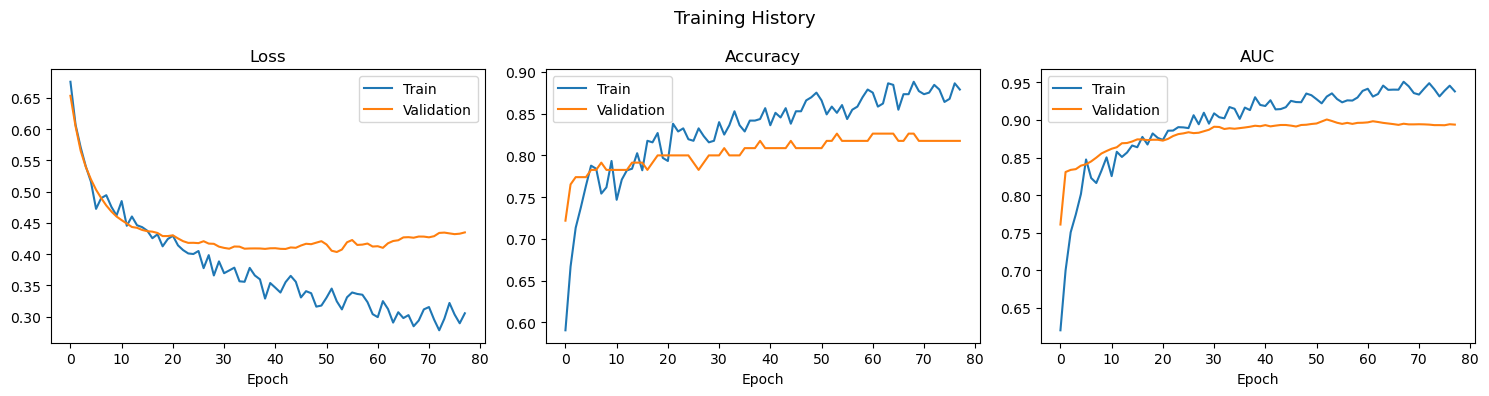

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('house_price_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
model.load_weights('best_diabetes.keras')

test_results = model.evaluate(X_test, Y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.4035
compile_metrics: 0.8174


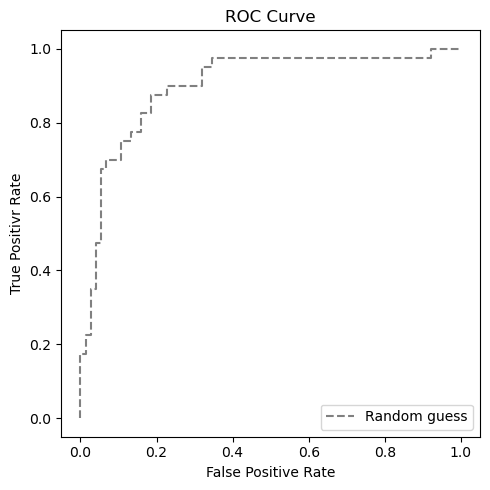

ROC-AUC: 0.8993


In [15]:
Y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(Y_test, Y_prob)

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

 No Diabetes       0.88      0.84      0.86        75
    Diabetes       0.72      0.78      0.75        40

    accuracy                           0.82       115
   macro avg       0.80      0.81      0.80       115
weighted avg       0.82      0.82      0.82       115



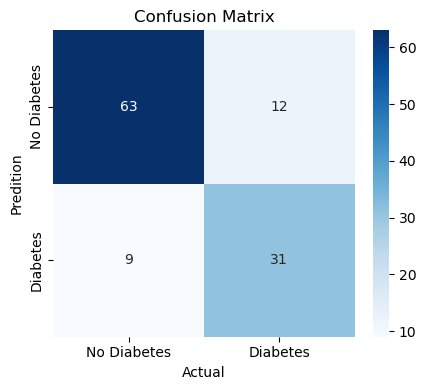

In [16]:
Y_pred = (Y_prob >= 0.5).astype(int)
import seaborn as sns

print(classification_report(Y_test, Y_pred, target_names=['No Diabetes', 'Diabetes']))

cm=confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Diabetes', 'Diabetes'],
           yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Actual')
plt.ylabel('Predition')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
model.save('diabetes_ann.keras')

with open('diabetes_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_scale,
        'feature_cols': feature_cols,
        'train_medians': train_medians,
    }, f)

print("Saved diabetes_ann.keras")
print("Saved diabetes_inference_kit.pkl")

Saved diabetes_ann.keras
Saved diabetes_inference_kit.pkl


In [19]:
def predict_patient(patient, model, feature_cols, scaler_mean, scaler_scale):
    patient=patient.copy()

    # Add the same extra features wa created during data preparation
    patient['Glucose_x_BMI']=patient['Glucose'] * patient['BMI']
    patient['Age_x_BMI']=patient['Age'] * patient['BMI']
    patient['impaired_glucose']=float(patient['Glucose'] >= 100)
    patient['diabetic_glucose']=float(patient['Glucose'] >= 126)
    patient['is_obese']=float(patient['BMI'] >= 30)
    patient['older_patient']=float(patient['Glucose'] >= 40)
    
    #Pur the feature in the exact same order the model expects
    row=np.array([patient[col] for col in feature_cols], dtype=np.float32)
    
        #Scale by hand: same formula the training data went through
    row_scaled = (row - scaler_mean) / scaler_scale
    row_scaled = row_scaled.reshape(1, -1)
    
    probability = model.predict(row_scaled, verbose=0)[0][0]
    prediction = 'Diabetes' if probability >= 0.5 else 'No Diabetes'
    
    print(f"Probability of diabetes: {probability:.1%}")
    print(f"Prediction: {prediction}")

In [24]:
patient_1={'Pregnancies': 6, 'Glucose':148, 'BloodPressure':72, 'SkinThickness': 35,
    'Insulin': 0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50,
}
print("patient 1 (actual: No Diabetes)")
predict_patient(patient_1, model, feature_cols, scaler_mean, scaler_scale)

print()

patient_2 = {
    'Pregnancies': 1, 'Glucose':85, 'BloodPressure':66, 'SkinThickness': 29,
    'Insulin': 0, 'BMI': 26.6, 'DiabetesPedigreeFunction': 0.351, 'Age': 31,
}
print("patient 2 (actual: No Diabetes)")
predict_patient(patient_2, model, feature_cols, scaler_mean, scaler_scale)

patient 1 (actual: No Diabetes)
Probability of diabetes: 0.3%
Prediction: No Diabetes

patient 2 (actual: No Diabetes)
Probability of diabetes: 0.0%
Prediction: No Diabetes
